In [29]:
#Instalaciones básicas
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import datetime
import sys
sys.path.append("..")

#Instalaciones de imputación de datos
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer

#Importaciones de soporte
from src import soporte as sp


In [2]:
df = pd.read_csv("../data/data_limpioscategoricos.csv", parse_dates=['date'])
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,id_
24481,NaN,management,married,high.school,no,yes,no,cellular,79,2,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,no,2018-11-21,f30d1f9a-012a-4384-aeff-2c0b1bd63c93
42881,24.0,blue-collar,single,basic,no,no,no,cellular,418,2,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no,2019-02-22,6977307b-22b2-4e47-80fc-f55165454de5
16242,29.0,blue-collar,single,basic,no,yes,no,cellular,262,1,999,0,nonexistent,1.4,93.918,-42.7,NaN,5228.1,no,2019-02-22,aac21c76-8e9c-404a-b0f2-02a77305a531
6272,37.0,technician,single,university.degree,no,yes,no,telephone,291,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2017-09-14,62860715-494e-4473-ac53-0bb71a7abafb
11985,42.0,blue-collar,married,basic,no,yes,yes,telephone,102,1,999,0,nonexistent,1.4,94.465,-41.8,4.947,5228.1,no,2015-01-04,2db8e81a-7773-4dd7-9c65-a3fdb5336c62


In [3]:
#Observamos las medidas de dispersion de las columnas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
age,37880.0,39.977112,17.0,32.0,38.0,47.0,98.0,10.437957
duration,43000.0,257.739279,0.0,102.0,179.0,319.0,4918.0,258.666033
campaign,43000.0,2.567233,1.0,1.0,2.0,3.0,56.0,2.772294
pdays,43000.0,962.330953,0.0,999.0,999.0,999.0,999.0,187.260394
previous,43000.0,0.174023,0.0,0.0,0.0,0.0,7.0,0.497366
emp.var.rate,43000.0,0.077128,-3.4,-1.8,1.1,1.4,1.4,1.573898
cons.price.idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
cons.conf.idx,43000.0,-40.509049,-50.8,-42.7,-41.8,-36.4,-26.9,4.637186
euribor3m,33744.0,3.616521,0.634,1.344,4.857,4.961,5.045,1.737117
nr.employed,43000.0,5166.852602,4963.6,5099.1,5191.0,5228.1,5228.1,72.411125


In [4]:
#Generamos una lsita de las columnas numericas
columnas_num = df.select_dtypes(include=np.number).columns.tolist()
columnas_num

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [5]:
#Generamos las medidas de dispersión de las columnas numericas
df[columnas_num].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37880.0,39.977112,10.437957,17.000,32.000,38.000,47.000,98.000
duration,43000.0,257.739279,258.666033,0.000,102.000,179.000,319.000,4918.000
campaign,43000.0,2.567233,2.772294,1.000,1.000,2.000,3.000,56.000
pdays,43000.0,962.330953,187.260394,0.000,999.000,999.000,999.000,999.000
previous,43000.0,0.174023,0.497366,0.000,0.000,0.000,0.000,7.000
emp.var.rate,43000.0,0.077128,1.573898,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,42529.0,93.574219,0.579548,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,43000.0,-40.509049,4.637186,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,33744.0,3.616521,1.737117,0.634,1.344,4.857,4.961,5.045
nr.employed,43000.0,5166.852602,72.411125,4963.600,5099.100,5191.000,5228.100,5228.100


# Analisis dispersión columnas numéricas
Age: Dispersión controlada. El rango completo (98 - 17 = 81) es amplio, pero la mayoría de los datos están contenidos dentro de un rango estrecho alrededor de la media.

Duration: Alta dispersión relativa (dispersión cercana a la media), indicando que los valores de duración varían considerablemente. Además, el valor máximo (4918) sugiere la presencia de posibles outliers extremos hacia la derecha.

Campaign: Dispersión moderada con algunos valores extremos (máx. = 56) que podrían indicar registros inusuales o repetidos contactos.

Pdays: Alta concentración en el valor 999, posiblemente indicando que no se contactó previamente al cliente. La variabilidad se ve afectada por este valor específico.

Previous: La mayoría de los valores son cero, lo que refleja una concentración extrema en valores bajos, con algunos pocos valores atípicos (máx. = 7). La variable está altamente sesgada.

emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m,nr.employed:	Desviaciones estándar bajas en relación a sus medias, indicando baja variabilidad y una distribución más compacta. Los cambios en estos valores son pequeños pero pueden tener impactos significativos.



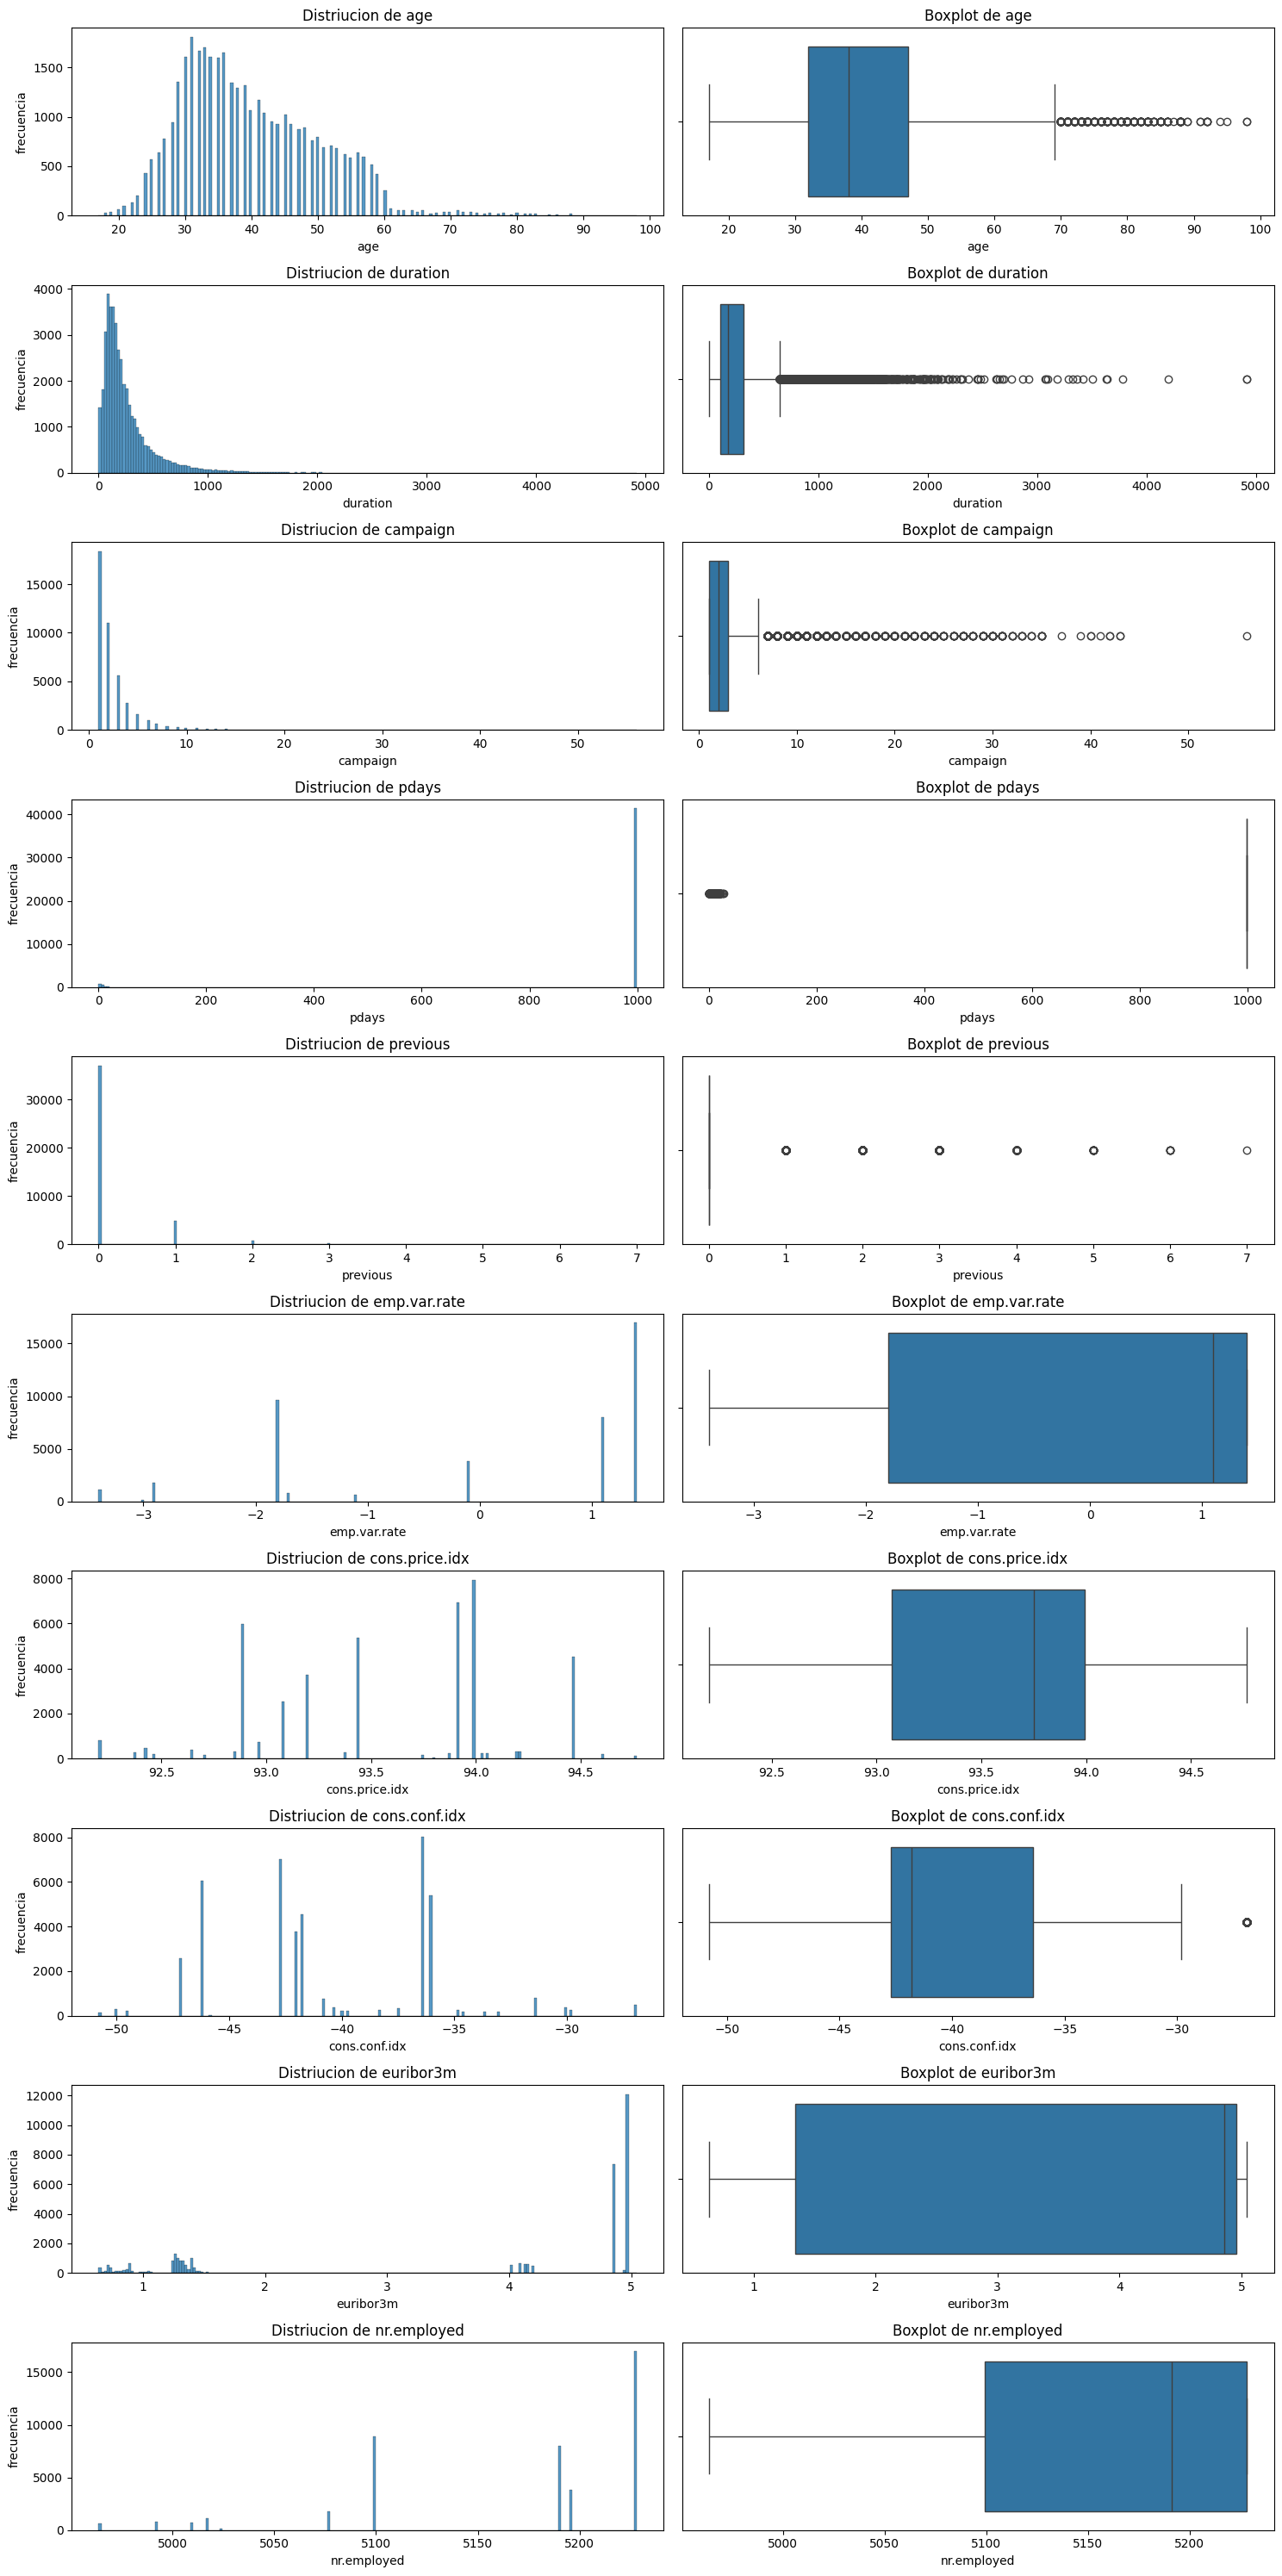

In [6]:
#Generamos subplots de las columnas numéricas
sp.subplot_col_num(df,columnas_num)

In [7]:
#Unico outlier por la izquierda
outlier_pdays = df['pdays'] [df['pdays']<999].count()
print(f"para la columna pdays tenemos {outlier_pdays}, lo que representa un {round(outlier_pdays/df.shape[0]*100,4)}%")

para la columna pdays tenemos 1588, lo que representa un 3.693%


In [8]:
#Generamos diccionario de outliers por la derecha
dicc_outliers = {'age':69,
                'duration':650,
                'campaign': 6.5,
                'previous': 0,
                'cons.conf.idx': -29}

In [9]:
# Analizamos ouliers por la derecha
sp.outliers_derecha(df,dicc_outliers)

para la columna AGE tenemos 441, lo que representa un 1.0256%
para la columna DURATION tenemos 3022, lo que representa un 7.0279%
para la columna CAMPAIGN tenemos 2504, lo que representa un 5.8233%
para la columna PREVIOUS tenemos 5897, lo que representa un 13.714%
para la columna CONS.CONF.IDX tenemos 477, lo que representa un 1.1093%


In [10]:
#Las columnas 'AGE' y 'CONS.CONF.IDX' podemos eliminar los outliers pues son muy bajos
df['age'] = df['age'].apply(lambda x: np.nan if x > 69 else x)
df['cons.conf.idx'] = df['cons.conf.idx'].apply(lambda x: np.nan if x > -29 else x)

# Gestion de nulos de las columnas numericas

In [11]:
total_nulos, porcentaje_total_nulos = sp.calcular_nulos(df)

In [12]:
total_nulos

age               5561
job                  0
marital              0
education            0
default              0
housing              0
loan                 0
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx      477
euribor3m         9256
nr.employed          0
y                    0
date              3760
id_                  0
dtype: int64

In [13]:
porcentaje_total_nulos

age               12.932558
job                0.000000
marital            0.000000
education          0.000000
default            0.000000
housing            0.000000
loan               0.000000
contact            0.000000
duration           0.000000
campaign           0.000000
pdays              0.000000
previous           0.000000
poutcome           0.000000
emp.var.rate       0.000000
cons.price.idx     1.095349
cons.conf.idx      1.109302
euribor3m         21.525581
nr.employed        0.000000
y                  0.000000
date               8.744186
id_                0.000000
dtype: float64

In [14]:
#Distinguimos columnas con muchos nulos y pocos nulos en base a si tienen más o menos de un 10%
col_high_umbral, col_low_umbral = sp.calcular_solo_col_nul(df)

,Column,Datatype,NullCount,Null%
0,age,float64,5561,12.932558
1,cons.price.idx,float64,471,1.095349
2,cons.conf.idx,float64,477,1.109302
3,euribor3m,float64,9256,21.525581
4,date,datetime64[ns],3760,8.744186


## Empezamos a gestionar nulos: columnas con % debajo del umbral.
- El umbral establecido es del 10%
- El metodo para imputar nulos va a ser el fillna()

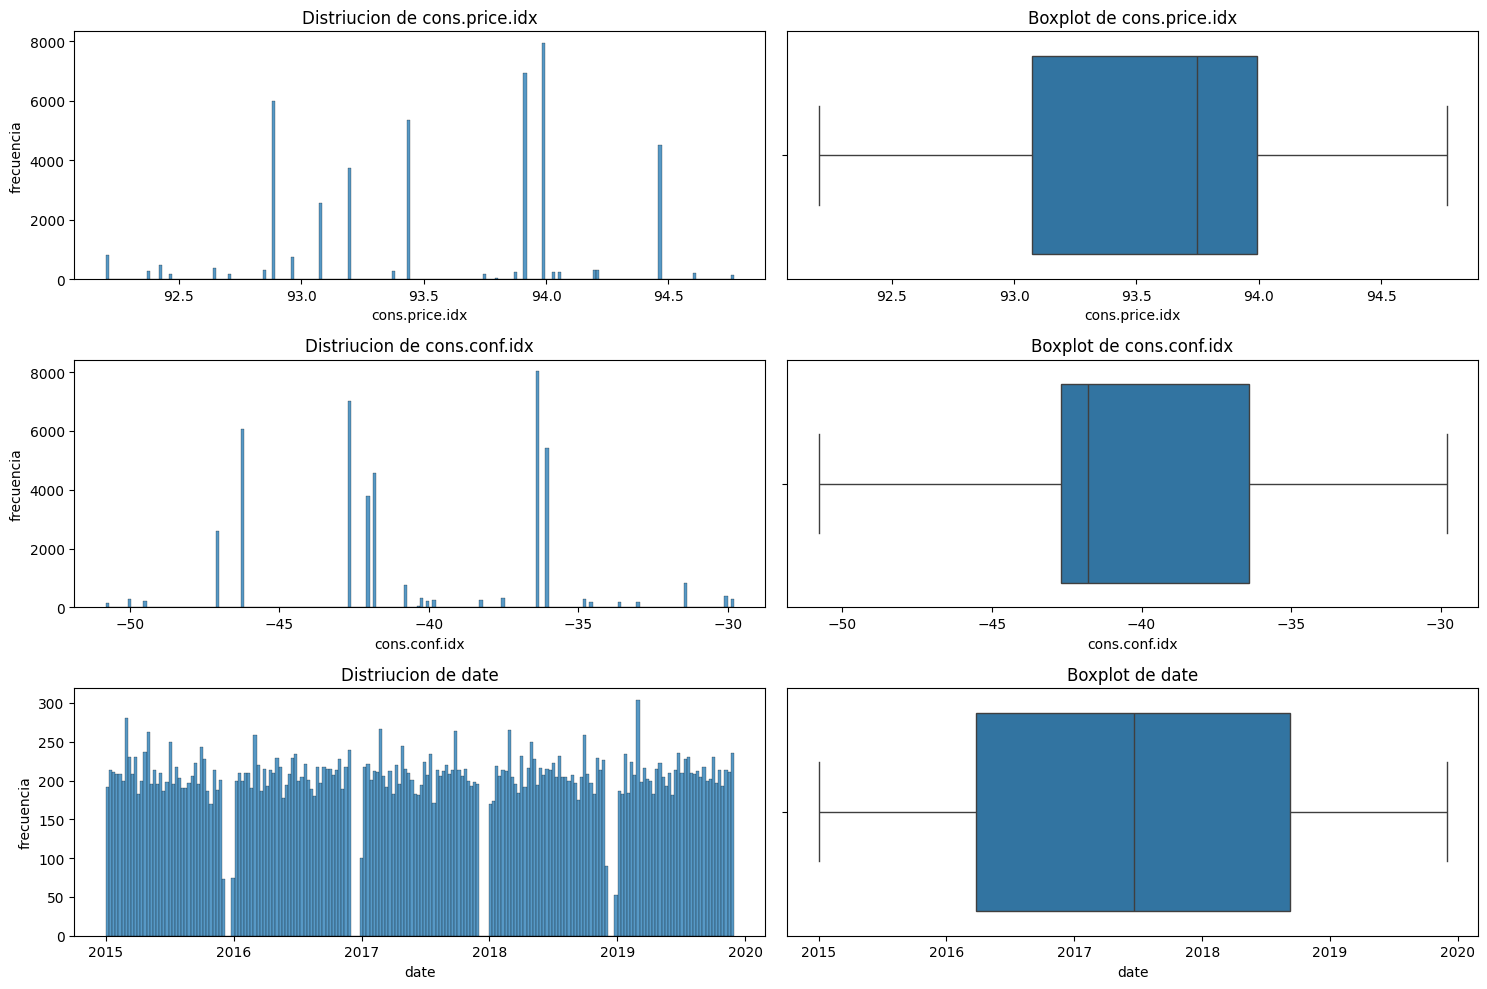

In [15]:
#Generamos subplots de las columnas con pocos nulos
sp.subplot_col_num(df, col_low_umbral)

In [16]:
df[col_low_umbral].describe().T

,count,mean,min,25%,50%,75%,max,std
cons.price.idx,42529.0,93.574219,92.201,93.075,93.749,93.994,94.767,0.579548
cons.conf.idx,42523.0,-40.661708,-50.8,-42.7,-41.8,-36.4,-29.8,4.432135
date,39240,2017-06-17 07:19:26.972476928,2015-01-01 00:00:00,2016-03-26 00:00:00,2017-06-19 00:00:00,2018-09-10 00:00:00,2019-11-30 00:00:00,NaN


In [17]:
#Rellenamos los nulos de 'cons.price.idx' y 'cons.conf.idx' con la media ya que los valores son muy próximos a la mediana y date con la mediana

df_filled_simple = df.fillna({
    'cons.price.idx':df['cons.price.idx'].mean(),
    'cons.conf.idx':df['cons.conf.idx'].mean(),
    'date':df['date'].median()
})

In [18]:
#Comprobamos como cambian los estadisticos
#Describe del dataframe nuevo
df_filled_simple[col_low_umbral].describe().T

,count,mean,min,25%,50%,75%,max,std
cons.price.idx,43000.0,93.574219,92.201,93.075,93.574219,93.994,94.767,0.576365
cons.conf.idx,43000.0,-40.661708,-50.8,-42.7,-41.8,-36.4,-29.8,4.407482
date,43000,2017-06-17 10:52:51.348837632,2015-01-01 00:00:00,2016-05-04 00:00:00,2017-06-19 00:00:00,2018-07-30 00:00:00,2019-11-30 00:00:00,NaN


Comprobamos cambios mínimos en los estadísticos. Procedemos a gestionar los nulos de nuestro df, con el que estamos trabajando, como hemos hecho en el df_filled_simple

In [19]:
#Rellenamos los nulos con lo descrito anteriormente
df = df.fillna({
    'cons.price.idx':df['cons.price.idx'].mean(),
    'cons.conf.idx':df['cons.conf.idx'].mean(),
    'date':df['date'].median()})

## Empezamos a gestionar nulos: columnas con % superior al umbral.
- El umbral establecido es del 10%
- El metodo para imputar nulos va a ser interative imputer

In [20]:
df[col_high_umbral].describe().T

,count,mean,std,min,25%,50%,75%,max
age,37439.0,39.541227,9.670787,17.000,32.000,38.000,47.000,69.000
euribor3m,33744.0,3.616521,1.737117,0.634,1.344,4.857,4.961,5.045


In [21]:
#Generamos datos con el metodo iterative imputer
iter_imputer = IterativeImputer(max_iter=50, random_state=42)
data_imputed = iter_imputer.fit_transform(df[col_high_umbral])
data_imputed

array([[40.28549566,  4.857     ],
       [57.        ,  3.92828159],
       [37.        ,  4.857     ],
       ...,
       [39.5240269 ,  3.61613806],
       [40.34747544,  4.958     ],
       [39.77247496,  4.021     ]], shape=(43000, 2))

In [22]:
#Generamos datos con el metodo iterative imputer y oberservamos dataframe
df, col_iterative = sp.imputar_iterative(df, col_high_umbral)

,count,mean,std,min,25%,50%,75%,max
age_iterative,43000.0,39.524027,9.030897,17.000,33.000,39.000,45.000,69.000
euribor3m_iterative,43000.0,3.616138,1.540617,0.634,1.466,4.076,4.959,5.045


In [23]:
#Generamos datos con el metodo knn imputer y oberservamos dataframe
df, col_knn = sp.imputar_knn(df, col_high_umbral)

,count,mean,std,min,25%,50%,75%,max
age_knn,43000.0,39.580237,9.128621,17.000,33.000,39.0000,45.000,69.000
euribor3m_knn,43000.0,3.605828,1.585098,0.634,1.445,4.2088,4.959,5.045


In [24]:
#Generamos un datafram con el knn y el iterative
col_imputadas = col_high_umbral + col_knn + col_iterative

In [25]:
df[col_imputadas].describe().sort_index(axis=1).T

,count,mean,std,min,25%,50%,75%,max
age,37439.0,39.541227,9.670787,17.000,32.000,38.0000,47.000,69.000
age_iterative,43000.0,39.524027,9.030897,17.000,33.000,39.0000,45.000,69.000
age_knn,43000.0,39.580237,9.128621,17.000,33.000,39.0000,45.000,69.000
euribor3m,33744.0,3.616521,1.737117,0.634,1.344,4.8570,4.961,5.045
euribor3m_iterative,43000.0,3.616138,1.540617,0.634,1.466,4.0760,4.959,5.045
euribor3m_knn,43000.0,3.605828,1.585098,0.634,1.445,4.2088,4.959,5.045


In [26]:
#Despues de comprobar los estadísticos eliminamos las columnas con nulos y KNN ya que en este caso es peor
df.drop(columns= col_knn + col_high_umbral, inplace=True)



In [27]:
df.to_csv('../data/data_a_analizar.csv', index=False, date_format='%Y-%m-%d')